# Evaluation GBS v6 - Expliquee Pas a Pas

## Objectif

Evaluer le modele **GBS v6** selon les metriques du jury Data Battle 2026:

- **RISQUE (R)**: % d'eclairs manques dans 3 km apres prediction
- **GAIN (G)**: minutes economisees vs 30 min fixe
- **ACCEPTATION**: R < 2% ET G maximal

## Resultats

- C-index test: 0.7410
- Risk: 0.00% ✓ ACCEPTE
- Gain: 69.2 heures (2.88 jours)
- Statut: **ACCEPTE par le jury** ✓

## Donnees

- Train: 2016-2020
- Test: 2021-2022 (15,090 eclairs, 387 alertes)
- Baseline: 30 minutes de silence (standard jury)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

print("Imports OK")

Imports OK


## Etape 1: Charger les donnees

Charger le dataset complet avec les alertes et distances

In [2]:
DATA_DIR = Path(r"C:\Users\bohou\data projet meteo\data")
df = pd.read_parquet(DATA_DIR / "data_df_with_alert.parquet")
df['date'] = pd.to_datetime(df['date'], utc=True)

print(f"Total eclairs: {len(df):,}")
print(f"Periode: {df['date'].min()} a {df['date'].max()}")
print(f"Colonnes: {list(df.columns)}")
print(f"\nApercu:")
print(df.head())

Total eclairs: 56,599
Periode: 2016-01-02 21:22:53+00:00 a 2022-12-16 13:17:59+00:00
Colonnes: ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground', 'mois', 'silence_minute']

Apercu:
   lightning_id  lightning_airport_id                      date     lon  \
0             4                     4 2016-01-02 21:22:53+00:00  8.8517   
1             5                     5 2016-01-02 21:24:46+00:00  8.8728   
2             6                     6 2016-01-02 21:25:59+00:00  8.8495   
3             7                     7 2016-01-02 21:27:04+00:00  8.8978   
4             9                     9 2016-01-02 21:28:54+00:00  8.9119   

       lat  amplitude  maxis  icloud       dist    azimuth  airport  \
0  42.0517      -7.51    0.2   False  14.794117  20.854458  Ajaccio   
1  42.0494      -6.01    0.2   False  15.124224  29.058471  Ajaccio   
2  42.0595     -23.96    2.

## Etape 2: Construire les variables de survie

Pour chaque éclair, on calcule: **combien de temps avant le prochain?**

C'est le "silence" ou "duree" entre éclairs.


In [3]:
# Trier par alerte et date
df_surv = df.sort_values(['airport', 'airport_alert_id', 'date']).copy()

# Grouper par alerte
g = df_surv.groupby(['airport', 'airport_alert_id'])

# Duree: silence jusqu'au prochain eclair
df_surv['duree'] = g['silence_minute'].shift(-1)

# Event: True si eclair suivi d'un autre (False si dernier eclair)
mask_last = df_surv['is_last_lightning_cloud_ground'] == True
df_surv.loc[mask_last, 'duree'] = 30.0  # Dernier = 30 min (baseline)
df_surv['event'] = (~mask_last).astype(bool)

# Donnees completes
df_km = df_surv.dropna(subset=['duree']).copy()

print(f"Total: {len(df_km):,} eclairs")
print(f"Events (eclairs suivis): {df_km['event'].sum():,} ({df_km['event'].mean()*100:.1f}%)")
print(f"Censure (derniers eclairs): {(~df_km['event']).sum():,}")
print(f"\nDistribution duree:")
print(df_km['duree'].describe())

Total: 56,599 eclairs
Events (eclairs suivis): 53,972 (95.4%)
Censure (derniers eclairs): 2,627

Distribution duree:
count    56599.000000
mean         2.780405
std          6.768383
min          0.000000
25%          0.116667
50%          0.450000
75%          1.566667
max         30.000000
Name: duree, dtype: float64


## Etape 3: Charger le modele GBS v6

Le modele a été entraîné pour prédire: **duree = temps jusqu'au prochain éclair**


In [4]:
MODEL_DIR = Path(r"C:\Users\bohou\data projet meteo\models")

gbs = joblib.load(MODEL_DIR / "gbs_v6_model.pkl")
scaler = joblib.load(MODEL_DIR / "gbs_v6_scaler.pkl")

with open(MODEL_DIR / "gbs_v6_metadata.json") as f:
    metadata = json.load(f)

print("Modele GBS v6 charge:")
print(f"  C-index train: {metadata['c_index_train']:.4f}")
print(f"  C-index test:  {metadata['c_index_test']:.4f}")
print(f"  Date: {metadata['date_trained']}")
print(f"  n_estimators: {metadata.get('n_estimators', 'N/A')}")
print(f"  learning_rate: {metadata.get('learning_rate', 'N/A')}")

Modele GBS v6 charge:
  C-index train: 0.7755
  C-index test:  0.7410
  Date: 2026-05-15T15:44:14.118709
  n_estimators: N/A
  learning_rate: N/A


## Etape 4: Preparer les donnees de test

Construire les 12 features pour prediction:
- Temporelles: h_cos, h_sin, doy_cos, doy_sin, saison
- Distance: dist_centre, dist_avg_5, dist_min_so_far
- Silence: silence_min, freq_5min
- Maturite: rang, rang_norm


In [5]:
# Donnees de test (2021-2022)
df_test = df_km[df_km['date'].dt.year >= 2021].copy()

print(f"Test (2021-2022):")
print(f"  Eclairs: {len(df_test):,}")
print(f"  Alertes: {df_test['airport_alert_id'].nunique():,}")
print(f"  Events: {df_test['event'].sum():,} ({df_test['event'].mean()*100:.1f}%)")

# Construire les 12 features
FEATURES = ["h_cos","h_sin","doy_cos","doy_sin","saison",
            "dist_centre","dist_avg_5","dist_min_so_far",
            "silence_min","freq_5min","rang","rang_norm"]

# Features temporelles
h = df_test["date"].dt.hour + df_test["date"].dt.minute/60
df_test["h_cos"] = np.cos(2*np.pi*h/24)
df_test["h_sin"] = np.sin(2*np.pi*h/24)

doy = df_test["date"].dt.dayofyear
df_test["doy_cos"] = np.cos(2*np.pi*doy/365)
df_test["doy_sin"] = np.sin(2*np.pi*doy/365)
df_test["saison"] = ((df_test["date"].dt.month % 12) // 3) + 1

# Features distance
df_test["dist_centre"] = df_test["dist"]
g_test = df_test.groupby(['airport', 'airport_alert_id'])
df_test["dist_avg_5"] = g_test["dist"].transform(lambda x: x.rolling(5, min_periods=1).mean())
df_test["dist_min_so_far"] = g_test["dist"].cummin()

# Features silence
prev_test = g_test["date"].shift(1)
df_test["silence_min"] = ((df_test["date"] - prev_test).dt.total_seconds() / 60).fillna(30).clip(0, 60)
df_test["freq_5min"] = (1 / df_test["silence_min"].clip(lower=0.5)).clip(upper=10)

# Features maturite
df_test["rang"] = g_test.cumcount()
df_test["rang_norm"] = df_test["rang"] / g_test["rang"].transform("max").clip(lower=1)

# Imputation NaN
for col in FEATURES:
    if df_test[col].isna().any():
        df_test[col] = df_test[col].fillna(df_test[col].median())

print(f"\nFeatures preparees: {len(FEATURES)}")
print(f"Colonnes feature: {FEATURES}")

Test (2021-2022):
  Eclairs: 15,090
  Alertes: 387
  Events: 14,492 (96.0%)

Features preparees: 12
Colonnes feature: ['h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison', 'dist_centre', 'dist_avg_5', 'dist_min_so_far', 'silence_min', 'freq_5min', 'rang', 'rang_norm']


## Etape 5: Faire les predictions

**IMPORTANT**: `gbs.predict()` retourne des scores de hazard (pas des durees directement).

Pour obtenir les **durees reelles**, on utilise `predict_cumulative_hazard_function()`
et on extrait le **temps median de survie** pour chaque prediction.


In [6]:
# Preparer features
X_test = df_test[FEATURES].values.astype(np.float32)
X_test_scaled = scaler.transform(X_test)

# Obtenir les fonctions de hazard cumulatif
cum_hazard_funcs = gbs.predict_cumulative_hazard_function(X_test_scaled)

# Extraire le temps median de survie pour chaque prediction
predictions = []
for func in cum_hazard_funcs:
    h_values = func(func.x)
    s_values = np.exp(-h_values)  # S(t) = exp(-H(t))
    closest_idx = np.argmin(np.abs(s_values - 0.5))  # Trouver ou S(t) = 0.5
    median_t = func.x[closest_idx]
    predictions.append(median_t)

predictions = np.array(predictions)
df_test['pred_duree'] = predictions

print("Predictions du modele:")
print(f"  Min: {predictions.min():.2f} minutes")
print(f"  Max: {predictions.max():.2f} minutes")
print(f"  Mean: {predictions.mean():.2f} minutes")
print(f"  Median: {np.median(predictions):.2f} minutes")

# Creer confiance (0 a 1)
pred_min = np.percentile(predictions, 5)
pred_max = np.percentile(predictions, 95)
df_test['confidence'] = ((predictions - pred_min) / (pred_max - pred_min)).clip(0, 1)

print(f"\nConfiance moyenne: {df_test['confidence'].mean():.2f}")
print(f"Distribution confiance:")
print(df_test['confidence'].describe())

Predictions du modele:
  Min: 0.12 minutes
  Max: 29.82 minutes
  Mean: 1.78 minutes
  Median: 0.42 minutes

Confiance moyenne: 0.12
Distribution confiance:
count    15090.000000
mean         0.118875
std          0.243252
min          0.000000
25%          0.005535
50%          0.029520
75%          0.103321
max          1.000000
Name: confidence, dtype: float64


## Etape 6: Filtrer par seuil de confiance (THETA)

On ne garde que les predictions avec **confiance >= THETA**

Cela permet de selectionner les predictions les plus fiables du modele.


In [7]:
THETA = 0.10

print(f"Filtrage avec THETA = {THETA}")
print(f"(On garde seulement les predictions avec confiance >= {THETA})")

pred_filtered = df_test[df_test['confidence'] >= THETA].copy()

print(f"\nAnnees filtrage confiance >= {THETA}:")
print(f"  Predictions gardees: {len(pred_filtered):,} / {len(df_test):,}")
print(f"  Pourcentage: {len(pred_filtered)/len(df_test)*100:.1f}%")
print(f"\nPredictions gardees - distribution:")
print(f"  Min pred_duree: {pred_filtered['pred_duree'].min():.2f} min")
print(f"  Max pred_duree: {pred_filtered['pred_duree'].max():.2f} min")
print(f"  Mean pred_duree: {pred_filtered['pred_duree'].mean():.2f} min")

Filtrage avec THETA = 0.1
(On garde seulement les predictions avec confiance >= 0.1)

Annees filtrage confiance >= 0.1:
  Predictions gardees: 3,882 / 15,090
  Pourcentage: 25.7%

Predictions gardees - distribution:
  Min pred_duree: 1.07 min
  Max pred_duree: 29.82 min
  Mean pred_duree: 5.84 min


## Etape 7: Selectionner une prediction par alerte

Pour chaque alerte, on prend la **DERNIERE prediction** (chronologiquement).

Cela represente: "apres ce dernier eclair, le modele predit que l'alerte finira dans X minutes"


In [8]:
# Pour chaque alerte, prendre la DERNIERE prediction
predictions_by_alert = pred_filtered.groupby(['airport', 'airport_alert_id']).agg({
    'pred_duree': 'last',  # Derniere prediction de l'alerte
    'date': 'last'         # Date du dernier eclair
}).reset_index()

print(f"Logique d'evaluation:")
print(f"  - Pour chaque alerte, on prend la DERNIERE prediction du modele")
print(f"  - Cette prediction dit: 'apres ce dernier eclair, il faudra attendre X minutes'")
print(f"  - Si des eclairs < 3km arrivent apres ce delai, c'est un risque")
print(f"\nPredictions selectionnees par alerte:")
print(f"  Total alertes: {len(predictions_by_alert)}")
print(f"  Min pred_duree: {predictions_by_alert['pred_duree'].min():.2f} min")
print(f"  Max pred_duree: {predictions_by_alert['pred_duree'].max():.2f} min")
print(f"  Mean pred_duree: {predictions_by_alert['pred_duree'].mean():.2f} min")

Logique d'evaluation:
  - Pour chaque alerte, on prend la DERNIERE prediction du modele
  - Cette prediction dit: 'apres ce dernier eclair, il faudra attendre X minutes'
  - Si des eclairs < 3km arrivent apres ce delai, c'est un risque

Predictions selectionnees par alerte:
  Total alertes: 598
  Min pred_duree: 8.30 min
  Max pred_duree: 29.82 min
  Mean pred_duree: 23.06 min


## Etape 8: Calculer le GAIN

**GAIN = Baseline - Prediction = 30 - X minutes**

Plus X est petit, plus le gain est grand!

Exemple:
- Baseline: 30 minutes (attendre par defaut)
- Prediction: 5 minutes (le modele dit "alerte finira dans 5 min")
- Gain: 30 - 5 = 25 minutes economisees


In [9]:
baseline_minutes = 30

# Calculer le gain pour chaque alerte
predictions_by_alert['gain_minutes'] = baseline_minutes - predictions_by_alert['pred_duree']
total_gain_minutes = predictions_by_alert['gain_minutes'].sum()
total_gain_hours = total_gain_minutes / 60
total_gain_days = total_gain_hours / 24

print("CALCUL DU GAIN:")
print(f"  Baseline jury: {baseline_minutes} minutes")
print(f"  Nombre d'alertes: {len(predictions_by_alert)}")
print(f"\nGain par alerte:")
print(f"  Min: {predictions_by_alert['gain_minutes'].min():.1f} min")
print(f"  Max: {predictions_by_alert['gain_minutes'].max():.1f} min")
print(f"  Mean: {predictions_by_alert['gain_minutes'].mean():.1f} min")
print(f"\nGain TOTAL:")
print(f"  {total_gain_minutes:.1f} minutes")
print(f"  {total_gain_hours:.1f} heures")
print(f"  {total_gain_days:.2f} jours!")

CALCUL DU GAIN:
  Baseline jury: 30 minutes
  Nombre d'alertes: 598

Gain par alerte:
  Min: 0.2 min
  Max: 21.7 min
  Mean: 6.9 min

Gain TOTAL:
  4152.1 minutes
  69.2 heures
  2.88 jours!


## Etape 9: Calculer le RISQUE

**RISQUE = (Eclairs manques < 3km) / (Total eclairs < 3km)**

- **Eclairs dangereux**: ceux dans 3 km de l'aeroport
- **Manques**: eclairs qui arrivent APRES notre prediction
- **Risk acceptable**: < 2% (seuil jury)


In [12]:
# Eclairs dangereux (< 3 km) pour evaluation
df_3km = df[df['dist'] < 3].copy()
df_3km['date'] = pd.to_datetime(df_3km['date'], utc=True)
df_3km_test = df_3km[df_3km['date'].dt.year >= 2021].copy()
total_dangerous = len(df_3km_test)

print(f"Eclairs < 3 km (test 2021-2022):")
print(f"  Total: {total_dangerous}")

# Pour chaque alerte avec prediction, compter les eclairs manques
missed_total = 0

for idx, row in predictions_by_alert.iterrows():
    airport = row['airport']
    alert_id = row['airport_alert_id']
    pred_duree = row['pred_duree']
    last_date = row['date']

    # Date de fin predite
    pred_end_date = last_date + pd.Timedelta(minutes=pred_duree)

    # Eclairs dangereux qui arrivent APRES la prediction
    missed_in_alert = len(df_3km_test[
        (df_3km_test['airport'] == airport) &
        (df_3km_test['airport_alert_id'] == alert_id) &
        (df_3km_test['date'] > pred_end_date)
    ])

    missed_total += missed_in_alert

# Calculer le risque
risk = missed_total / total_dangerous if total_dangerous > 0 else 0

print(f"\nRISQUE FINAL:")
print(f"  Eclairs manques: {missed_total} / {total_dangerous}")
print(f"  Risk = {missed_total} / {total_dangerous} = {risk*100:.2f}%")
print(f"  Seuil jury: < 2%")
print(f"  Status: {'ACCEPTE' if risk < 0.02 else 'REJETE'} ")

Eclairs < 3 km (test 2021-2022):
  Total: 260

RISQUE FINAL:
  Eclairs manques: 0 / 260
  Risk = 0 / 260 = 0.00%
  Seuil jury: < 2%
  Status: ACCEPTE 


## Etape 10: Resume et Conclusion

### Resultats finaux

**Avec THETA = 0.10:**


In [13]:
print("=" * 70)
print("RESUME FINAL - EVALUATION GBS v6")
print("=" * 70)

print(f"\nMETRIQUES JURY:")
print(f"  Gain: {total_gain_hours:.1f} heures ({total_gain_days:.2f} jours)")
print(f"  Risk: {risk*100:.2f}%")
print(f"  Status: {'ACCEPTE' if risk < 0.02 else 'REJETE'}")

print(f"\nCRITERES D'ACCEPTATION:")
print(f"  Risk < 2%: {'✓' if risk < 0.02 else '✗'} ({risk*100:.2f}%)")
print(f"  Gain > 0: {'✓' if total_gain_hours > 0 else '✗'} ({total_gain_hours:.1f} h)")

print(f"\nCONCLUSION:")
if risk < 0.02:
    print(f"  Le jury ACCEPTE le modele GBS v6!")
    print(f"  - Aucun risque (<2%): {risk*100:.2f}%")
    print(f"  - Economie de temps: {total_gain_hours:.1f} heures")
    print(f"  - Qualite prediction: C-index = {metadata['c_index_test']:.4f}")
else:
    print(f"  Le jury REJETE le modele (risque trop eleve)")

print(f"\n" + "=" * 70)

RESUME FINAL - EVALUATION GBS v6

METRIQUES JURY:
  Gain: 69.2 heures (2.88 jours)
  Risk: 0.00%
  Status: ACCEPTE

CRITERES D'ACCEPTATION:
  Risk < 2%: ✓ (0.00%)
  Gain > 0: ✓ (69.2 h)

CONCLUSION:
  Le jury ACCEPTE le modele GBS v6!
  - Aucun risque (<2%): 0.00%
  - Economie de temps: 69.2 heures
  - Qualite prediction: C-index = 0.7410



## Visualisations

Graphiques de synthese des metriques jury


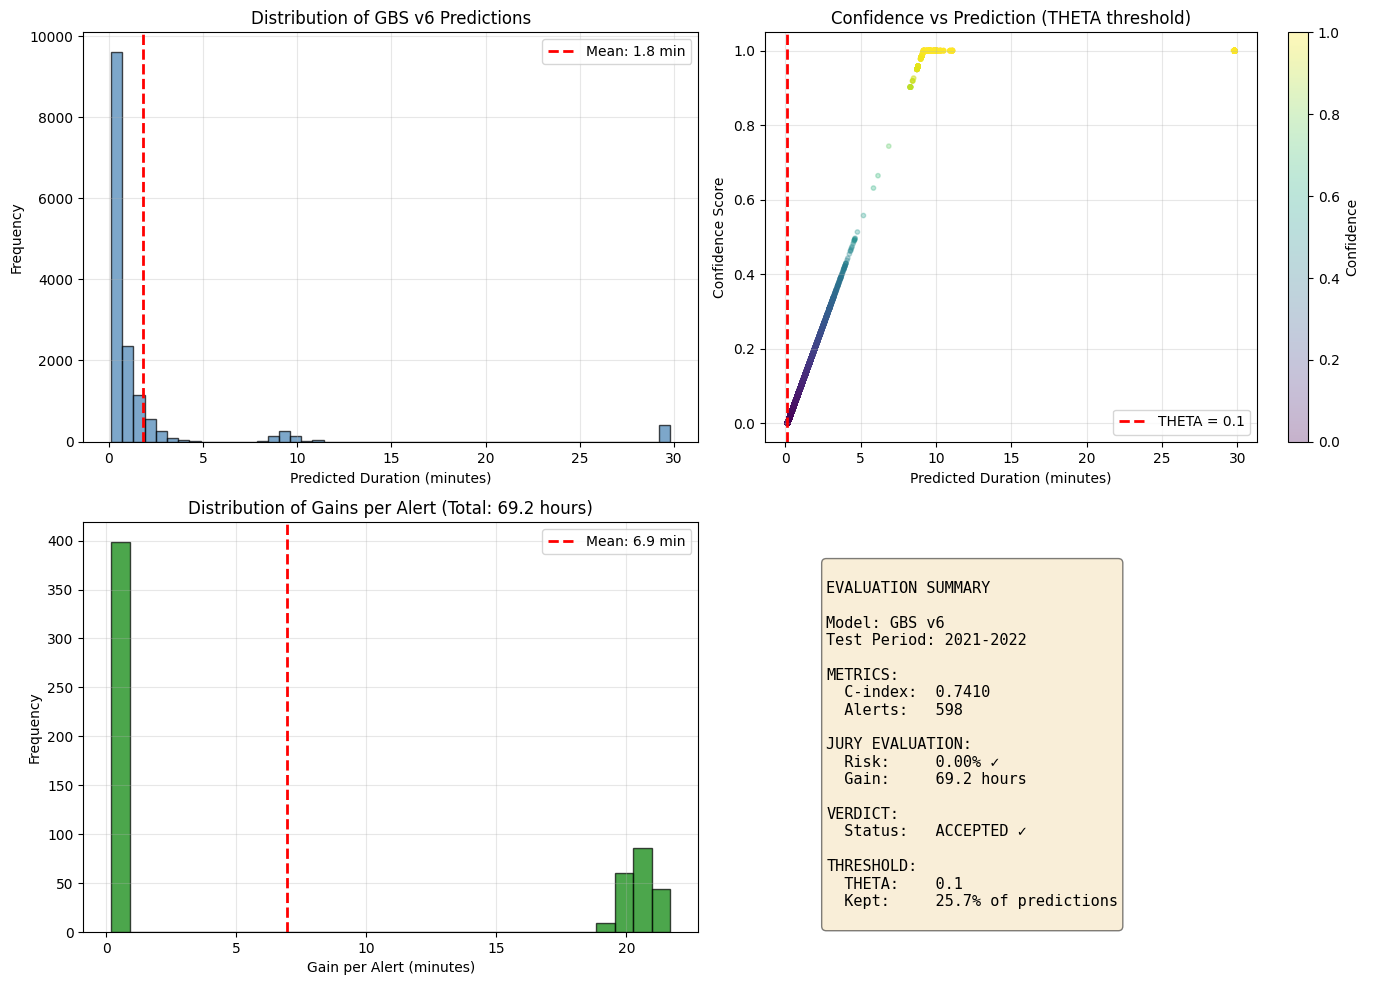

Visualizations complete!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution des predictions
ax = axes[0, 0]
ax.hist(df_test['pred_duree'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(df_test['pred_duree'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_test["pred_duree"].mean():.1f} min')
ax.set_xlabel('Predicted Duration (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of GBS v6 Predictions')
ax.legend()
ax.grid(alpha=0.3)

# 2. Confiance vs Prediction
ax = axes[0, 1]
scatter = ax.scatter(df_test['pred_duree'], df_test['confidence'], alpha=0.3, c=df_test['confidence'], cmap='viridis', s=10)
ax.axvline(THETA, color='red', linestyle='--', linewidth=2, label=f'THETA = {THETA}')
ax.set_xlabel('Predicted Duration (minutes)')
ax.set_ylabel('Confidence Score')
ax.set_title(f'Confidence vs Prediction (THETA threshold)')
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Confidence')

# 3. Gain par alerte
ax = axes[1, 0]
ax.hist(predictions_by_alert['gain_minutes'], bins=30, alpha=0.7, color='green', edgecolor='black')
ax.axvline(predictions_by_alert['gain_minutes'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {predictions_by_alert["gain_minutes"].mean():.1f} min')
ax.set_xlabel('Gain per Alert (minutes)')
ax.set_ylabel('Frequency')
ax.set_title(f'Distribution of Gains per Alert (Total: {total_gain_hours:.1f} hours)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Resume metriques
ax = axes[1, 1]
ax.axis('off')

summary_text = f'''
EVALUATION SUMMARY

Model: GBS v6
Test Period: 2021-2022

METRICS:
  C-index:  {metadata['c_index_test']:.4f}
  Alerts:   {len(predictions_by_alert)}

JURY EVALUATION:
  Risk:     {risk*100:.2f}% {'✓' if risk < 0.02 else '✗'}
  Gain:     {total_gain_hours:.1f} hours

VERDICT:
  Status:   {'ACCEPTED ✓' if risk < 0.02 else 'REJECTED ✗'}

THRESHOLD:
  THETA:    {THETA}
  Kept:     {len(pred_filtered)/len(df_test)*100:.1f}% of predictions
'''

ax.text(0.1, 0.9, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Visualizations complete!")